# Clase 11 — Estadística Descriptiva

Trabajas en el área de análisis de una consultora inmobiliaria. Un cliente quiere invertir en propiedades en Argentina y necesita un informe que responda preguntas concretas sobre el mercado antes de tomar cualquier decisión.

Te acaban de mandar acceso a un dataset real de Properati, uno de los portales inmobiliarios más grandes de América Latina, con miles de propiedades publicadas en Argentina. No está limpio, no está listo para analizar, y nadie te va a decir qué problemas tiene. Tu trabajo es encontrarlos, limpiarlos y responder las preguntas del cliente con números que puedas defender.

## Obtener el dataset

El dataset está disponible en Kaggle de forma gratuita:

👉 **[Properati Argentina Dataset — Kaggle](https://www.kaggle.com/datasets/alejandroczernikier/properati-argentina-dataset)**

Descarga el archivo CSV y guardalo en la misma carpeta donde vas a trabajar. Después cargalo:

In [29]:
import pandas as pd

df = pd.read_csv("/workspaces/data-analysis-course/modulo-3-transformacion/clase-11/practica/entrenamiento.csv")
#43020 rows × 25 columns

## Ejercicio 1 — Exploración inicial: ¿qué hay adentro?

Antes de responder cualquier pregunta del cliente, necesitás entender con qué estás trabajando. No asumas nada — explorá.

**Consigna:** Sin limpiar nada todavía, responde estas preguntas en comentarios:

- ¿Cuántas propiedades y cuántas columnas tiene el dataset?
- ¿Qué columnas numéricas hay? ¿Cuáles vas a necesitar para el análisis?
- ¿Cuántos nulos tiene cada columna relevante? (precio, superficie, ambientes, provincia, tipo de propiedad)
- ¿Hay columnas con nombres en inglés que debas entender antes de continuar? Renombra al menos las columnas principales a español.
- ¿Qué tipos de propiedad hay? ¿Qué provincias aparecen?
- ¿Cuáles tienen más registros?

In [30]:
df.shape #Nos dice que el dataset tiene 43020 registros, para 25 columnas.
df.dtypes #Columnas numericas: id, lat, long, l6, rooms, bedrooms, bathrooms, surface total
#surface_covered, price
df[["price", "surface_total", "surface_covered", "property_type", "l2"]].isnull().sum() #Para contar los nulos relevantes

price               2567
surface_total      14026
surface_covered    14505
property_type          1
l2                     1
dtype: int64

In [31]:
tipos_de_propiedades = df.groupby("property_type")["id"].count().sort_values(ascending=False)
print(tipos_de_propiedades)
en_provincias = df.groupby("l2")["id"].count().sort_values(ascending=False)
print(en_provincias)


property_type
Departamento       23062
Casa                8376
Lote                3919
PH                  2275
Local comercial     2114
Oficina             1267
Otro                 960
Cochera              587
Depósito             403
Casa de campo         56
Name: id, dtype: int64
l2
Capital Federal                 16812
Bs.As. G.B.A. Zona Norte         5782
Bs.As. G.B.A. Zona Sur           4976
Santa Fe                         3495
Bs.As. G.B.A. Zona Oeste         2550
Buenos Aires Costa Atlántica     2400
Córdoba                          1956
Buenos Aires Interior            1182
Mendoza                           753
Maldonado                         604
Neuquén                           404
Tucumán                           367
Montevideo                        337
Entre Ríos                        303
Río Negro                         244
Misiones                          159
Salta                             130
San Luis                           83
La Pampa                  

## Ejercicio 2 — Limpieza: decisiones justificadas

El dataset tiene problemas que van a afectar el análisis si no los tratás antes.

**Consigna:** Aplica las siguientes limpiezas y justifica cada decisión en un comentario:

- Quedate solo con propiedades en venta en USD (filtra por operation = 'sell' y currency = 'USD'). Responde ¿Por qué tiene sentido trabajar solo en USD?
- Eliminar filas donde el precio o la superficie sean nulos ¿Qué porcentaje del dataset estás perdiendo?
- Filtrar precios que parezcan errores evidentes ¿Tiene sentido una propiedad que vale $1 USD? ¿Y una de $50 millones?.Define un criterio para filtrar y justificalo.
- Quedate solo con los tipos de propiedad principales (por ejemplo: Departamento, Casa, PH) ¿Por qué descartas los demás?
- Al terminar: ¿cuántas filas quedaron? ¿Qué porcentaje del original?

In [32]:
df_limpio = df.copy()
df_limpio = df_limpio.rename(columns={'l1' : 'pais'})
df_limpio = df_limpio.rename(columns={'l2' : 'provincia'})
df_limpio = df_limpio.rename(columns={'l3' : 'barrio'})
df_limpio = df_limpio.rename(columns={'surface_total' : 'superficie_total'})
df_limpio = df_limpio.rename(columns={'surface_covered' : 'superficie_cubierta'})
df_limpio = df_limpio.rename(columns={'currency' : 'moneda'})
df_limpio = df_limpio.rename(columns={'property_type' : 'tipo_propiedad'})
df_limpio = df_limpio.rename(columns={'price' : 'precio'})
df_limpio = df_limpio.dropna(subset=["superficie_total", "superficie_cubierta", "precio"])
df_limpio = df_limpio[df["l1"] == "Argentina"]

tipos_permitidos = ["Departamento", "Casa", "PH", "Lote", "Local comercial", "Oficina"]
es_usd = df_limpio["moneda"] == "USD"
es_venta = df_limpio["operation_type"] == "Venta"
es_tipo_valido = df_limpio["tipo_propiedad"].isin(tipos_permitidos)

df_limpio = df_limpio[es_usd & es_venta & es_tipo_valido].copy()

#df_limpio.shape -------- Nos quedaron 16314 registros limpios.
df_limpio.head()

limite_inferior = df_limpio["precio"].quantile(0.01)
limite_superior = df_limpio["precio"].quantile(0.99)

print(f"Límite mínimo considerado: ${limite_inferior:,.2f} USD")
print(f"Límite máximo considerado: ${limite_superior:,.2f} USD")


df_limpio = df_limpio[
    (df_limpio["precio"] >= limite_inferior) & 
    (df_limpio["precio"] <= limite_superior)
].copy()

df_limpio.shape # ------ Luego de eliminar precios con errores evidentes nos quedan 15991 registros.

Límite mínimo considerado: $36,000.00 USD
Límite máximo considerado: $1,500,000.00 USD


/tmp/ipykernel_2802/3590627829.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_limpio = df_limpio[df["l1"] == "Argentina"]


(15991, 25)

Teníamos 43020 registros y nos quedaron 15991. 
Se perdió aproximadamente un 63% de los registros.

## Ejercicio 3 — Estadísticos del mercado general

Con el dataset limpio, calculá los estadísticos principales del precio en dólares para todo el mercado.

**Consigna:** Calcula para precio_usd, la media, mediana, moda, desviación estándar y percentiles 10, 25, 50, 75, 90, 99. Después responde en comentarios:

1. ¿La media y la mediana son similares o muy distintas? ¿Qué te dice esa diferencia sobre la distribución de precios?
2. ¿Entre qué valores se encuentra el 80% central de las propiedades? (entre P10 y P90)
3. ¿Cuánto cuesta el 1% más caro del mercado? ¿Eso afecta la media?
4. Grafica la distribución de precios con un histograma que muestre la media y la mediana como líneas verticales

In [33]:
media_precio = df_limpio["precio"].mean()
print(f"Precio medio: ${media_precio:,.0f}")
mediana_precio = df_limpio["precio"].median()
print(f"Precio mediana: ${mediana_precio:,.0f}")
moda_precio = df_limpio["precio"].mode()[0]
print(f"Precio moda: ${moda_precio:,.0f}")
desviacion_std = df_limpio['precio'].std()
print(f"Desviacion estandar: ${desviacion_std:,.0f}")
p10 = df_limpio['precio'].quantile(0.10)
p25 = df_limpio['precio'].quantile(0.25)
p50 = df_limpio['precio'].quantile(0.50)
p75 = df_limpio['precio'].quantile(0.75)
p90 = df_limpio['precio'].quantile(0.90)
p99 = df_limpio['precio'].quantile(0.99)
print (f"p10: $ {p10:,.0f}")
print (f"p25: $ {p25:,.0f} - El 25% de las propiedades cuesta menos que esto")
print (f"p50: $ {p50:,.0f} - La mediana")
print (f"p75: $ {p75:,.0f} - El 75% de las propiedades cuesta menos que esto")
print (f"p90: $ {p90:,.0f} - El 90% de las propiedades cuesta menos que esto")
print (f"p99: $ {p99:,.0f}")

Precio medio: $211,278
Precio mediana: $155,000
Precio moda: $120,000
Desviacion estandar: $186,755
p10: $ 72,500
p25: $ 100,000 - El 25% de las propiedades cuesta menos que esto
p50: $ 155,000 - La mediana
p75: $ 250,000 - El 75% de las propiedades cuesta menos que esto
p90: $ 398,000 - El 90% de las propiedades cuesta menos que esto
p99: $ 1,072,000


1. La media y la mediana son muy distintas. La media es bastante más alta que la mediana, hay una diferencia de casi 56 mil dólares. Esto nos dice que la gran mayoría de las propiedades tienen precios moderados (alrededor de los 120 mil o 155 mil dólares), pero existe un grupo reducido de propiedades muy caras que estiran la media hacia arriba. Por eso, la -mediana- (155 mil dólares) representa mucho mejor el valor de una casa 'central' que la -media-.
2. El 80% de las propiedades cuestan entre 72 mil y 400 mil dólares.
3. El 1% más caro cuesta a partir de un millón de dólares. Este precio afecta de forma directa la media. Tener propiedades que valen más de 1 millón de dólares (cuando la mitad del mercado cuesta menos de 155 mil) "infla" la media hasta los 211 mil. En cambio, la mediana no se ve afectada por estas cifras desproporcionadas porque solo le importa la posición del dato central.


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


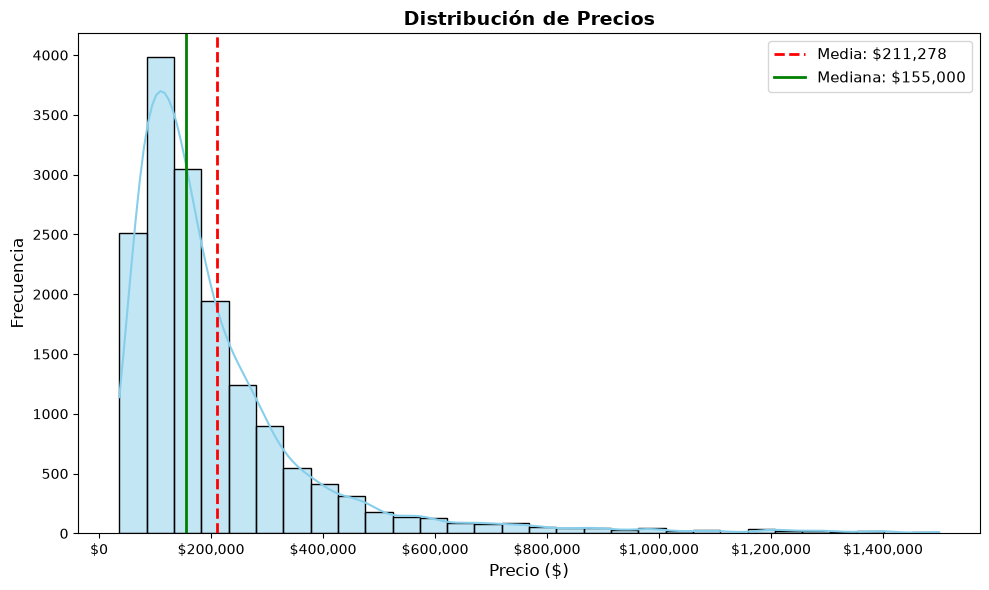

In [34]:
import matplotlib.pyplot as plt
!pip install seaborn
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    df_limpio["precio"], kde=True, color="skyblue", bins=30, edgecolors="black"
)
plt.axvline(
    x=media_precio,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Media: ${media_precio:,.0f}",
)
plt.axvline(
    x=mediana_precio,
    color="green",
    linestyle="-",
    linewidth=2,
    label=f"Mediana: ${mediana_precio:,.0f}",
)
plt.title("Distribución de Precios", fontsize=14, fontweight="bold")
plt.xlabel("Precio ($)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)

plt.gca().xaxis.set_major_formatter("${x:,.0f}")
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

## Ejercicio 4 — Precio por metro cuadrado: el indicador real

El precio absoluto de una propiedad no dice mucho sin contexto. El precio por metro cuadrado es el indicador estándar del sector para comparar mercados.

**Consigna:**

1. Calculá una columna nueva: precio_m2 = precio_usd / superficie_m2
2. Calculá media, mediana y desviación estándar de precio_m2 por tipo de propiedad
3. ¿Qué tipo de propiedad tiene el precio por m² más alto? ¿Tiene sentido para el mercado argentino?
4. Graficá la distribución de precio_m2 para cada tipo de propiedad en el mismo histograma (usá alpha=0.5 para transparencia)

    tipo_propiedad         media      mediana  desviacion_estandar
1     Departamento   2850.505109  2659.574468          1276.281344
5               PH   2219.334111  2169.811321           861.892405
4          Oficina   2581.384407  2157.894737          2504.599083
2  Local comercial   2566.595999  1953.488372          2156.205705
0             Casa   1675.082676  1428.571429          5387.378520
3             Lote  10791.269972  1187.500000         51632.094189


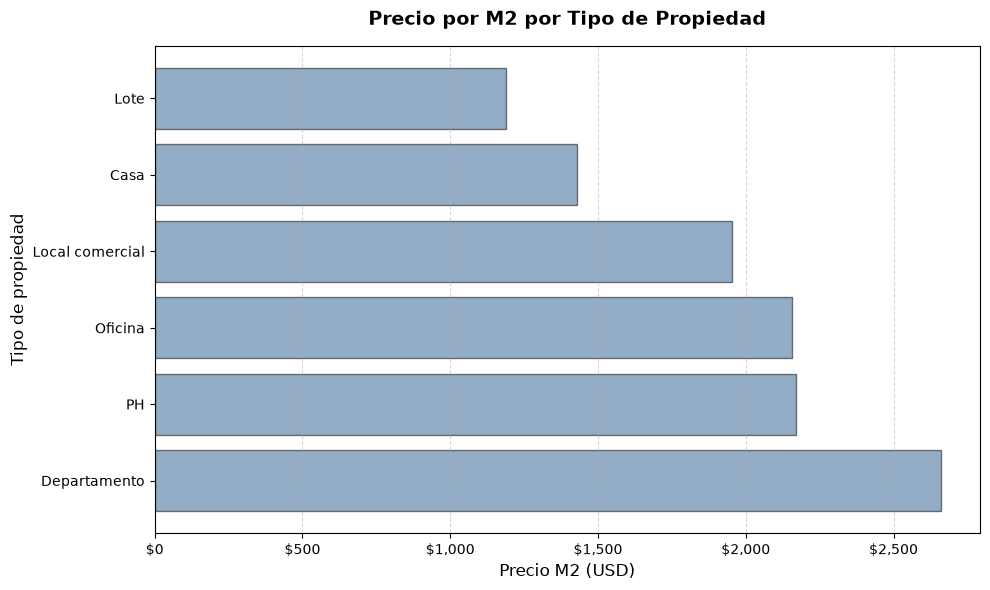

In [46]:
df_limpio['precio_m2'] = df_limpio['precio'] / df_limpio['superficie_cubierta']

resumen_m2 = df_limpio.groupby('tipo_propiedad')['precio_m2'].agg(
    media='mean',
    mediana='median',
    desviacion_estandar = 'std',
).reset_index()

resumen_m2 = resumen_m2.sort_values(by='mediana', ascending=False)
print(resumen_m2)

grafico = resumen_m2.sort_values(by='mediana', ascending=False)

plt.figure(figsize=(10,6))

plt.barh(
    grafico['tipo_propiedad'],
    grafico['mediana'],
    color='#2b5c8f', 
    edgecolor='black', 
    alpha=0.5
)

plt.title('Precio por M2 por Tipo de Propiedad', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Precio M2 (USD)', fontsize=12)
plt.ylabel('Tipo de propiedad', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.gca().xaxis.set_major_formatter('${x:,.0f}')

plt.tight_layout()
plt.show()

## Ejercicio 5 — Comparación entre provincias

El cliente todavía no decidió en qué provincia invertir. Necesita comparar los mercados.

**Consigna:** Calcula para cada provincia (con al menos 50 propiedades en el dataset), el precio mediano en USD, precio por m² mediano, desviación estándar del precio y cantidad de propiedades disponibles. Luego grafica el precio mediano por provincia en un gráfico de barras horizontal ordenado de mayor a menor.

Después responde:
1. ¿Qué provincia tiene el mercado más caro en precio absoluto?
2. ¿Y en precio por m²? ¿Es la misma?
3. ¿Qué provincia tiene el mercado más homogéneo (menor desviación estándar relativa a la media)?
4. ¿Hay alguna provincia donde la diferencia entre media y mediana sea especialmente grande? ¿Qué puede explicar eso?

                       provincia  precio_mediano_usd  precio_mediano_m2  \
0       Bs.As. G.B.A. Zona Norte            250000.0        1978.021978   
4          Buenos Aires Interior            220000.0        1443.939394   
8                        Neuquén            185000.0        2357.142857   
5                Capital Federal            159000.0        2823.529412   
7                        Mendoza            135500.0        1125.880282   
1       Bs.As. G.B.A. Zona Oeste            130000.0        1547.619048   
9                      Río Negro            129000.0        1805.945946   
2         Bs.As. G.B.A. Zona Sur            110000.0        1569.805195   
10                      Santa Fe            102000.0        1803.689065   
6                        Córdoba            100000.0        1100.000000   
3   Buenos Aires Costa Atlántica             98000.0        1746.875000   

    desviacion_estandar_precio  cantidad_propiedades  
0                239101.000061              

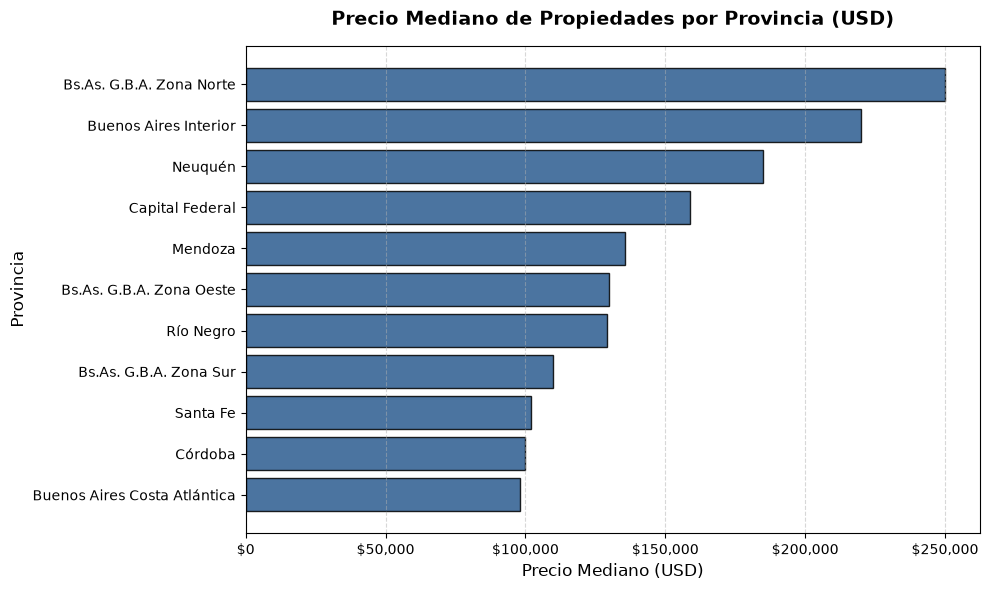

In [40]:
conteo_provincias = df_limpio['provincia'].value_counts()
provincias_validas = conteo_provincias[conteo_provincias >=50].index

df_limpio['precio_m2'] = df_limpio['precio'] / df_limpio['superficie_cubierta']

df_filtro = df_limpio[df_limpio['provincia'].isin(provincias_validas)]

resumen_provincias = df_filtro.groupby('provincia').agg(
    precio_mediano_usd = ('precio', 'median'),
    precio_mediano_m2 = ('precio_m2', 'median'),
    desviacion_estandar_precio = ('precio', 'std'),
    cantidad_propiedades = ('precio', 'count'),
).reset_index()

resumen_provincias = resumen_provincias.sort_values(by='precio_mediano_usd', ascending=False)

print(resumen_provincias)

resumen_grafico = resumen_provincias.sort_values(by='precio_mediano_usd', ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    resumen_grafico['provincia'], 
    resumen_grafico['precio_mediano_usd'], 
    color='#2b5c8f', 
    edgecolor='black', 
    alpha=0.85
)

plt.title('Precio Mediano de Propiedades por Provincia (USD)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Precio Mediano (USD)', fontsize=12)
plt.ylabel('Provincia', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Formatear el eje X con signo monetario y separador de miles
plt.gca().xaxis.set_major_formatter('${x:,.0f}')

plt.tight_layout()
plt.show()

1. En precio absoluto, lo más costoso es la zona norte de Buenos Aires. 
2. El precio de m2 más caro es de Capital Federal.
3. Mendoza es la provincia que registra menor desviación estándar.

## Ejercicio 6 — Correlaciones: qué factores explican el precio

El cliente quiere saber qué características de una propiedad impactan más en su precio.

**Consigna:**

1. Antes de calcular nada, anotá tus predicciones:
    - superficie_m2 vs precio_usd: ¿positiva, negativa, sin relación?
    - rooms (ambientes) vs precio_usd: ¿positiva, negativa, sin relación?
    - superficie_m2 vs rooms: ¿positiva, negativa, sin relación?

2. Calcula la matriz de correlación entre las variables numéricas relevantes

3. ¿Cuántas predicciones acertaste? Para las que no acertaste, ¿qué puede explicar la diferencia?
4. ¿Cuál es la variable que más se correlaciona con el precio? ¿Es lo que esperabas?
```

In [37]:
# tu código acá

## Ejercicio 7 — Comparación estadística por tipo de propiedad
 
El cliente todavía no definió si quiere invertir en un departamento, una casa o un PH. Necesita comparar los tres mercados usando todos los estadísticos que calculaste hasta ahora.
 
**Consigna:** Para cada tipo de propiedad (Departamento, Casa, PH), calcula la media, mediana del precio_usd, desviación estándar del precio_usd, media y mediana del precio_m2 y los percentiles 25 y 75 del precio_usd. Luego muestra el resultado como una tabla comparativa.
 
Por ultimo responde en comentarios:

1. ¿En qué tipo de propiedad la diferencia entre media y mediana es mayor? ¿Qué implica eso para el cliente que quiere saber "cuánto cuesta típicamente"?
2. ¿Qué tipo de propiedad tiene mayor dispersión de precios? ¿Eso es bueno o malo para un inversor que quiere predecir costos?
3. ¿El tipo más caro en precio absoluto también es el más caro en precio por m²? ¿Qué le dirías al cliente sobre esto?
4. ¿En qué tipo de propiedad el rango intercuartil (P75 - P25) es más amplio? ¿Qué dice eso sobre la homogeneidad de ese mercado?
5. Grafica la distribución de precios para los tres tipos en el mismo histograma (usa alpha=0.5 para transparencia y una leyenda que los diferencie)

In [38]:
# tu código acá

## Informe para el cliente

Con todo el análisis hecho, escribí un bloque de código que genere un reporte ejecutivo respondiendo estas preguntas concretas del cliente:

1. **¿Cuánto cuesta una propiedad "típica" en Argentina?** (usa el estadístico que mejor represente eso y justificá por qué)

2. **¿Cuál es la provincia con mejor relación precio/m²?**

3. **¿Cuánto impacta la superficie en el precio?** (usa la correlación para responder)

4. **¿Hay alguna provincia donde el mercado sea especialmente volátil?** (usa la desviación estándar para responder)

5. **¿Cuál es el rango de precios donde se encuentra la mayor parte del mercado?** (usa percentiles para definir ese rango)

In [39]:
print("=" * 56)
print("INFORME DE MERCADO INMOBILIARIO — ARGENTINA")
print("Fuente: Properati Argentina Dataset")
print("=" * 56)

# Tu reporte acá — cada punto respondido con números concretos
# y una oración de interpretación para el cliente

INFORME DE MERCADO INMOBILIARIO — ARGENTINA
Fuente: Properati Argentina Dataset


→ [Ver solución orientativa](./solucion.md) *(intenta primero — en este ejercicio no hay una única respuesta correcta)*